Connected to shocks (Python 3.10.18)

In [ ]:
""" FLD curve accoring to Elad's script (MATLAB: start from 1 with indices, * is matrix multiplication, ' is .T). """
abspath = '/Users/paolamartire/shocks'
import sys
sys.path.append(abspath)
#%% import resource
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import healpy as hp
from sklearn.neighbors import KDTree
from src.Opacity.interpolator_vectorized import calc_planck_opacity_vectorized, calc_ross_opacity_vectorized, calc_scattering_opacity_vectorized
import matplotlib.pyplot as plt
import Utilities.prelude as prel
from Utilities.selectors_for_snap import select_prefix
from Utilities.sections import make_slices
from Utilities.operators import make_tree, choose_observers, to_spherical_components
from src import orbits as orb
from src.Wind.Rtrapp_tdiff import load_and_adjust_rtrap

def single_fld(loadpath, snap, observers_xyz, N_ray):
    num_obs = len(observers_xyz)
    data = make_tree(loadpath, snap)
    box = np.load(f'{loadpath}/box_{snap}.npy')
    X, Y, Z, T, Den = \
        data.X, data.Y, data.Z, data.Temp, data.Den
    denmask = Den > 1e-19
    X, Y, Z, T, Den = \
        make_slices([X, Y, Z, T, Den], denmask)
    xyz = np.array([X, Y, Z]).T

    all_obs = {}
    for i in range(num_obs):
        # if i not in [0, 90]:
        #     continue
        print(f'Obs: {i}', flush=True)

        mu_x = observers_xyz[i][0]
        mu_y = observers_xyz[i][1]
        mu_z = observers_xyz[i][2]

        # be sure is normalized, but it should be because it's a healpy vector
        norm_mu = np.sqrt(mu_x**2 + mu_y**2 + mu_z**2)
        if norm_mu != 1.:
            print('normalizing observers direction. norm:', norm_mu, flush=True)
            mu_x /= norm_mu
            mu_y /= norm_mu
            mu_z /= norm_mu

        if mu_x < 0:
            rmax = box[0] / mu_x
        else:
            rmax = box[3] / mu_x
        if mu_y < 0:
            rmax = min(rmax, box[1] / mu_y)
        else:
            rmax = min(rmax, box[4] / mu_y)
        if mu_z < 0:
            rmax = min(rmax, box[2] / mu_z)
        else:
            rmax = min(rmax, box[5] / mu_z)

        r = np.logspace(-0.25, np.log10(rmax), N_ray)

        x = r*mu_x
        y = r*mu_y
        z = r*mu_z
        xyz2 = np.array([x, y, z]).T
        del x, y, z
        # find the simulation cell corresponding to cells in the wanted ray
        tree = KDTree(xyz, leaf_size=50) 
        _, idx = tree.query(xyz2, k=1)
        idx = idx.ravel()
        d = Den[idx] * prel.den_converter
        t = T[idx]

        alpha_scatter = calc_scattering_opacity_vectorized(T_cool, Rho_cool, scattering, np.log(t), np.log(d))
        alpha_scatter = np.array(alpha_scatter)
        alpha_rossland = calc_ross_opacity_vectorized(T_cool, Rho_cool, rossland, scattering, np.log(t), np.log(d))
        alpha_rossland = np.array(alpha_rossland)
        alpha_planck = calc_planck_opacity_vectorized(T_cool, Rho_cool, planck, np.log(t), np.log(d))
        alpha_planck = np.array(alpha_planck)
        
        underflow_mask = np.logical_and(np.logical_and(np.log(alpha_rossland) != 0.0, np.log(alpha_planck) != 0.0), np.log(alpha_scatter) != 0.0)
        d, t, r, alpha_rossland, alpha_planck, alpha_scatter = \
            make_slices([d, t, r, alpha_rossland, alpha_planck, alpha_scatter], underflow_mask)
        
        single_obs = {'r': r, 
                      'd': d, 
                      't': t, 
                      'alpha_rossland': alpha_rossland, 
                      'alpha_planck': alpha_planck, 
                      'alpha_scatter': alpha_scatter}

        key = f'obs_{i}'
        all_obs[key] = single_obs

    return all_obs

Estimated t_dyn: 1.24 days
Estimated t_fb: 0.48
Estimated t_diff: 110.84 days


Choice: left_right_z
Sections: ['left', 'right', 'north', 'south']
Total coverage: 192/192
Overlaps: 0
Adjusting observers number


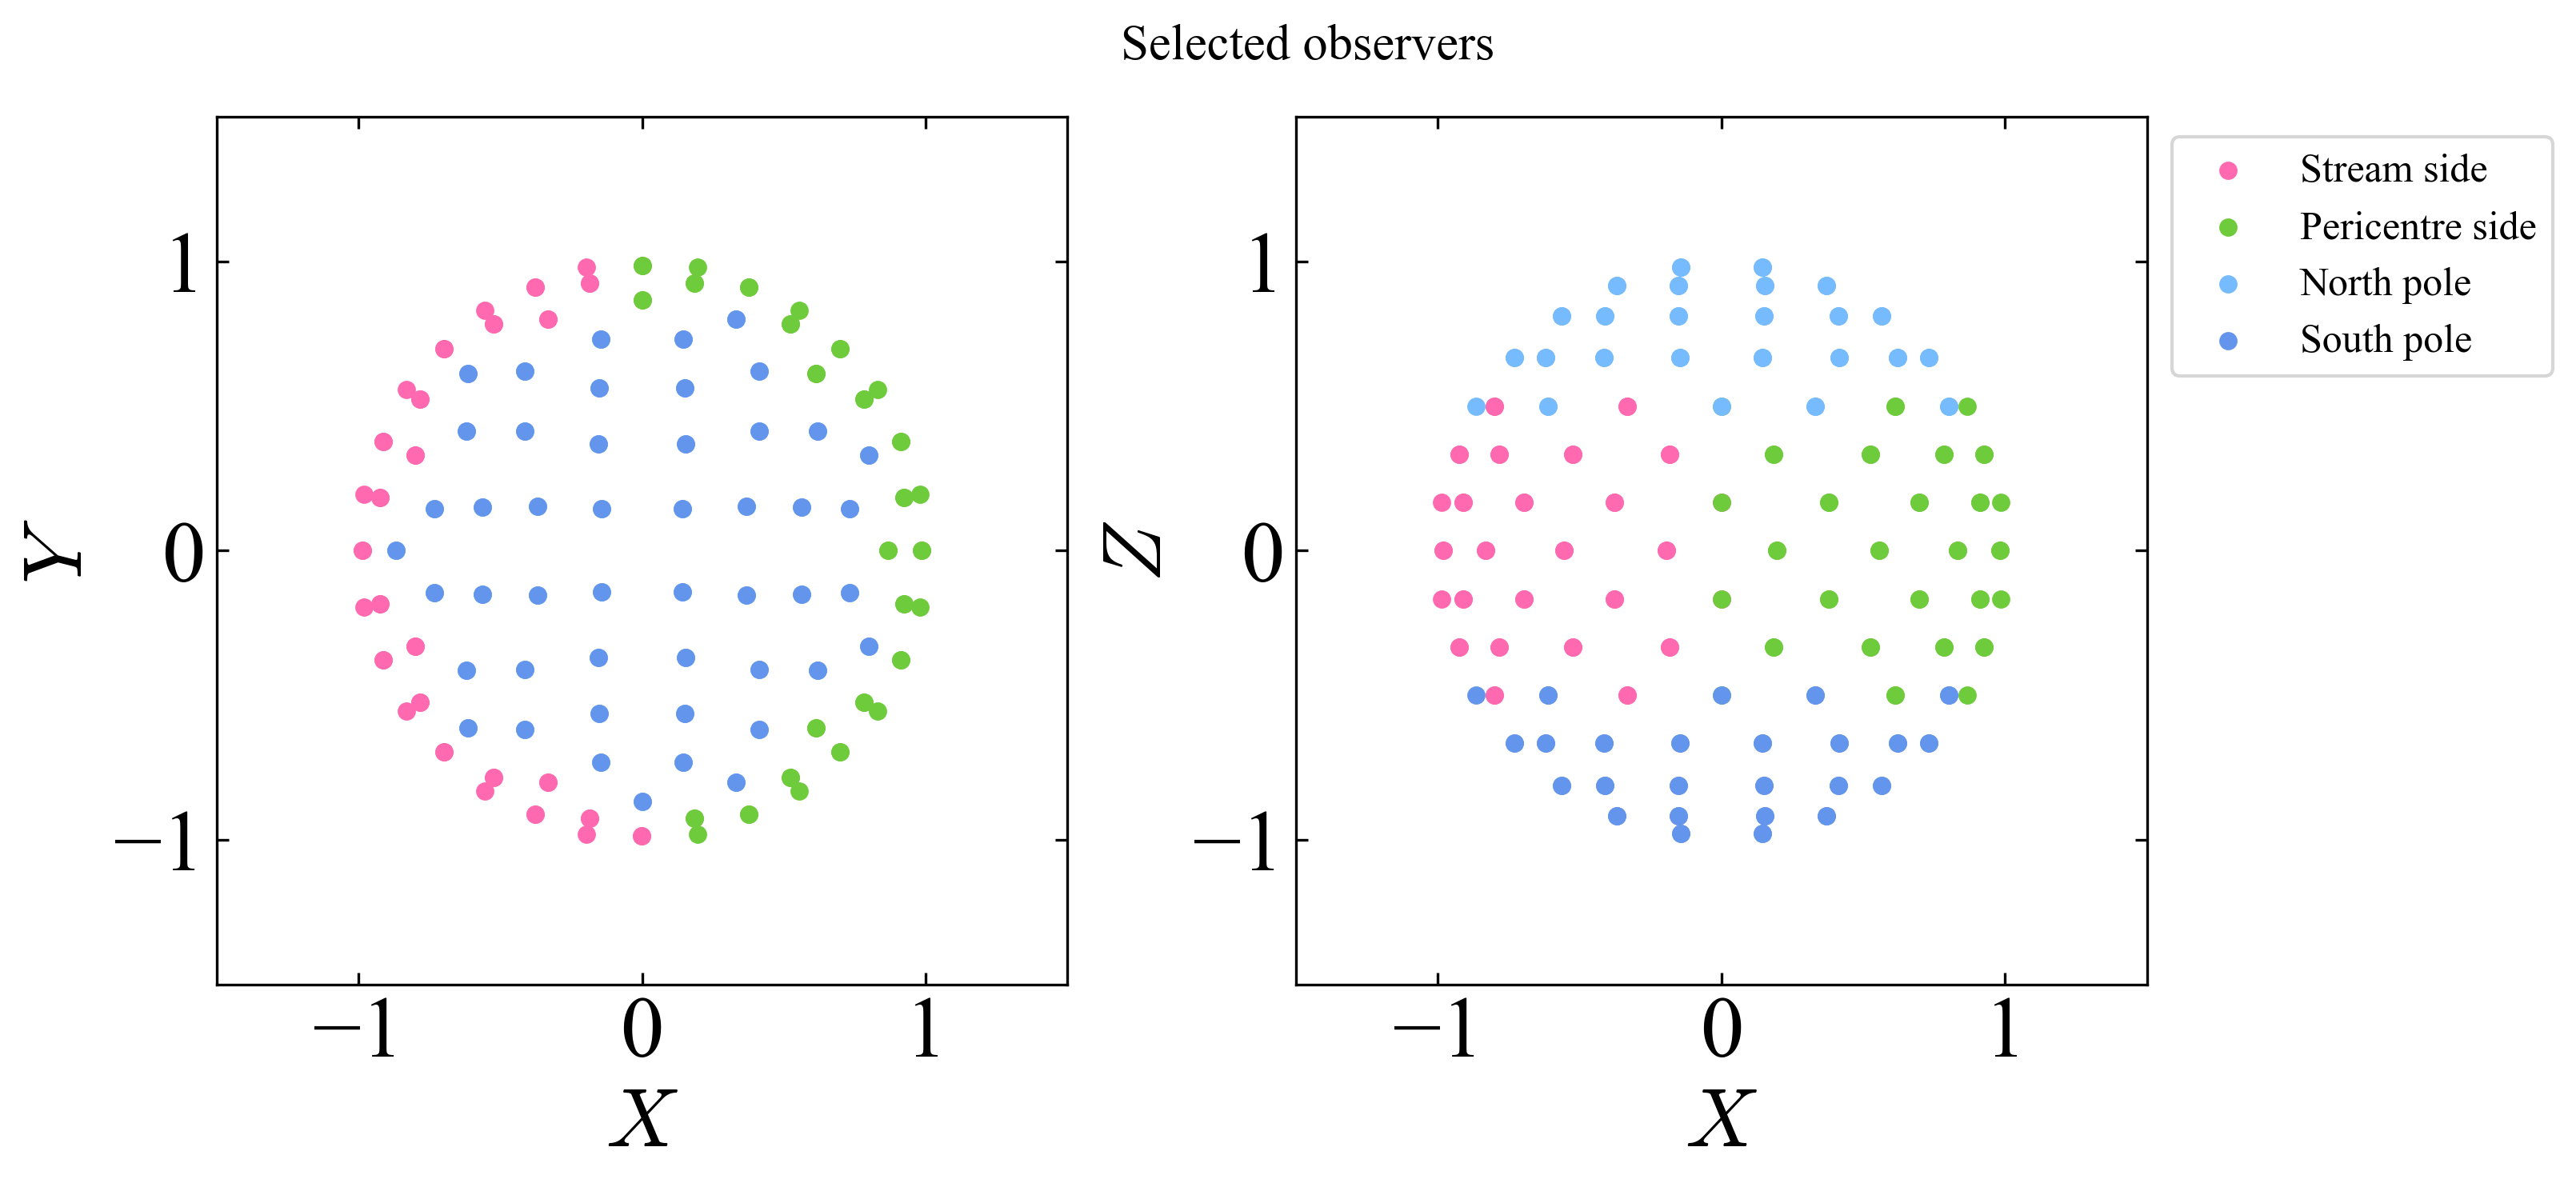

In [ ]:
m = 4
Mbh = 10**m
beta = 1
mstar = .5
Rstar = .47
n = 1.5
compton = 'Compton'
check = 'HiResNewAMR' 
snap = 151
N_ray = 1_000
params = [Mbh, Rstar, mstar, beta]
things = orb.get_things_about(params)
Rt = things['Rt']
pre = select_prefix(m, check, mstar, Rstar, beta, n, compton)
folder = f'R{Rstar}M{mstar}BH{Mbh}beta{beta}S60n{n}{compton}{check}'
pre_saving = f'{abspath}/data/{folder}'
loadpath = f'{pre}/{snap}'
which_obs = 'left_right_z'

observers_xyz = hp.pix2vec(prel.NSIDE, range(prel.NPIX)) # shape: (3, 192)
indices_obs, label_obs, colors_obs, _ = choose_observers(observers_xyz, which_obs)
observers_xyz = np.array(observers_xyz).T

# Load opacity tables
opac_path = f'{abspath}/src/Opacity'
T_cool = np.loadtxt(f'{opac_path}/T.txt')
Rho_cool = np.loadtxt(f'{opac_path}/rho.txt')
rossland = np.loadtxt(f'{opac_path}/ross.txt')
planck = np.loadtxt(f'{opac_path}/planck.txt')
scattering = np.loadtxt(f'{opac_path}/scatter.txt') # 1/cm

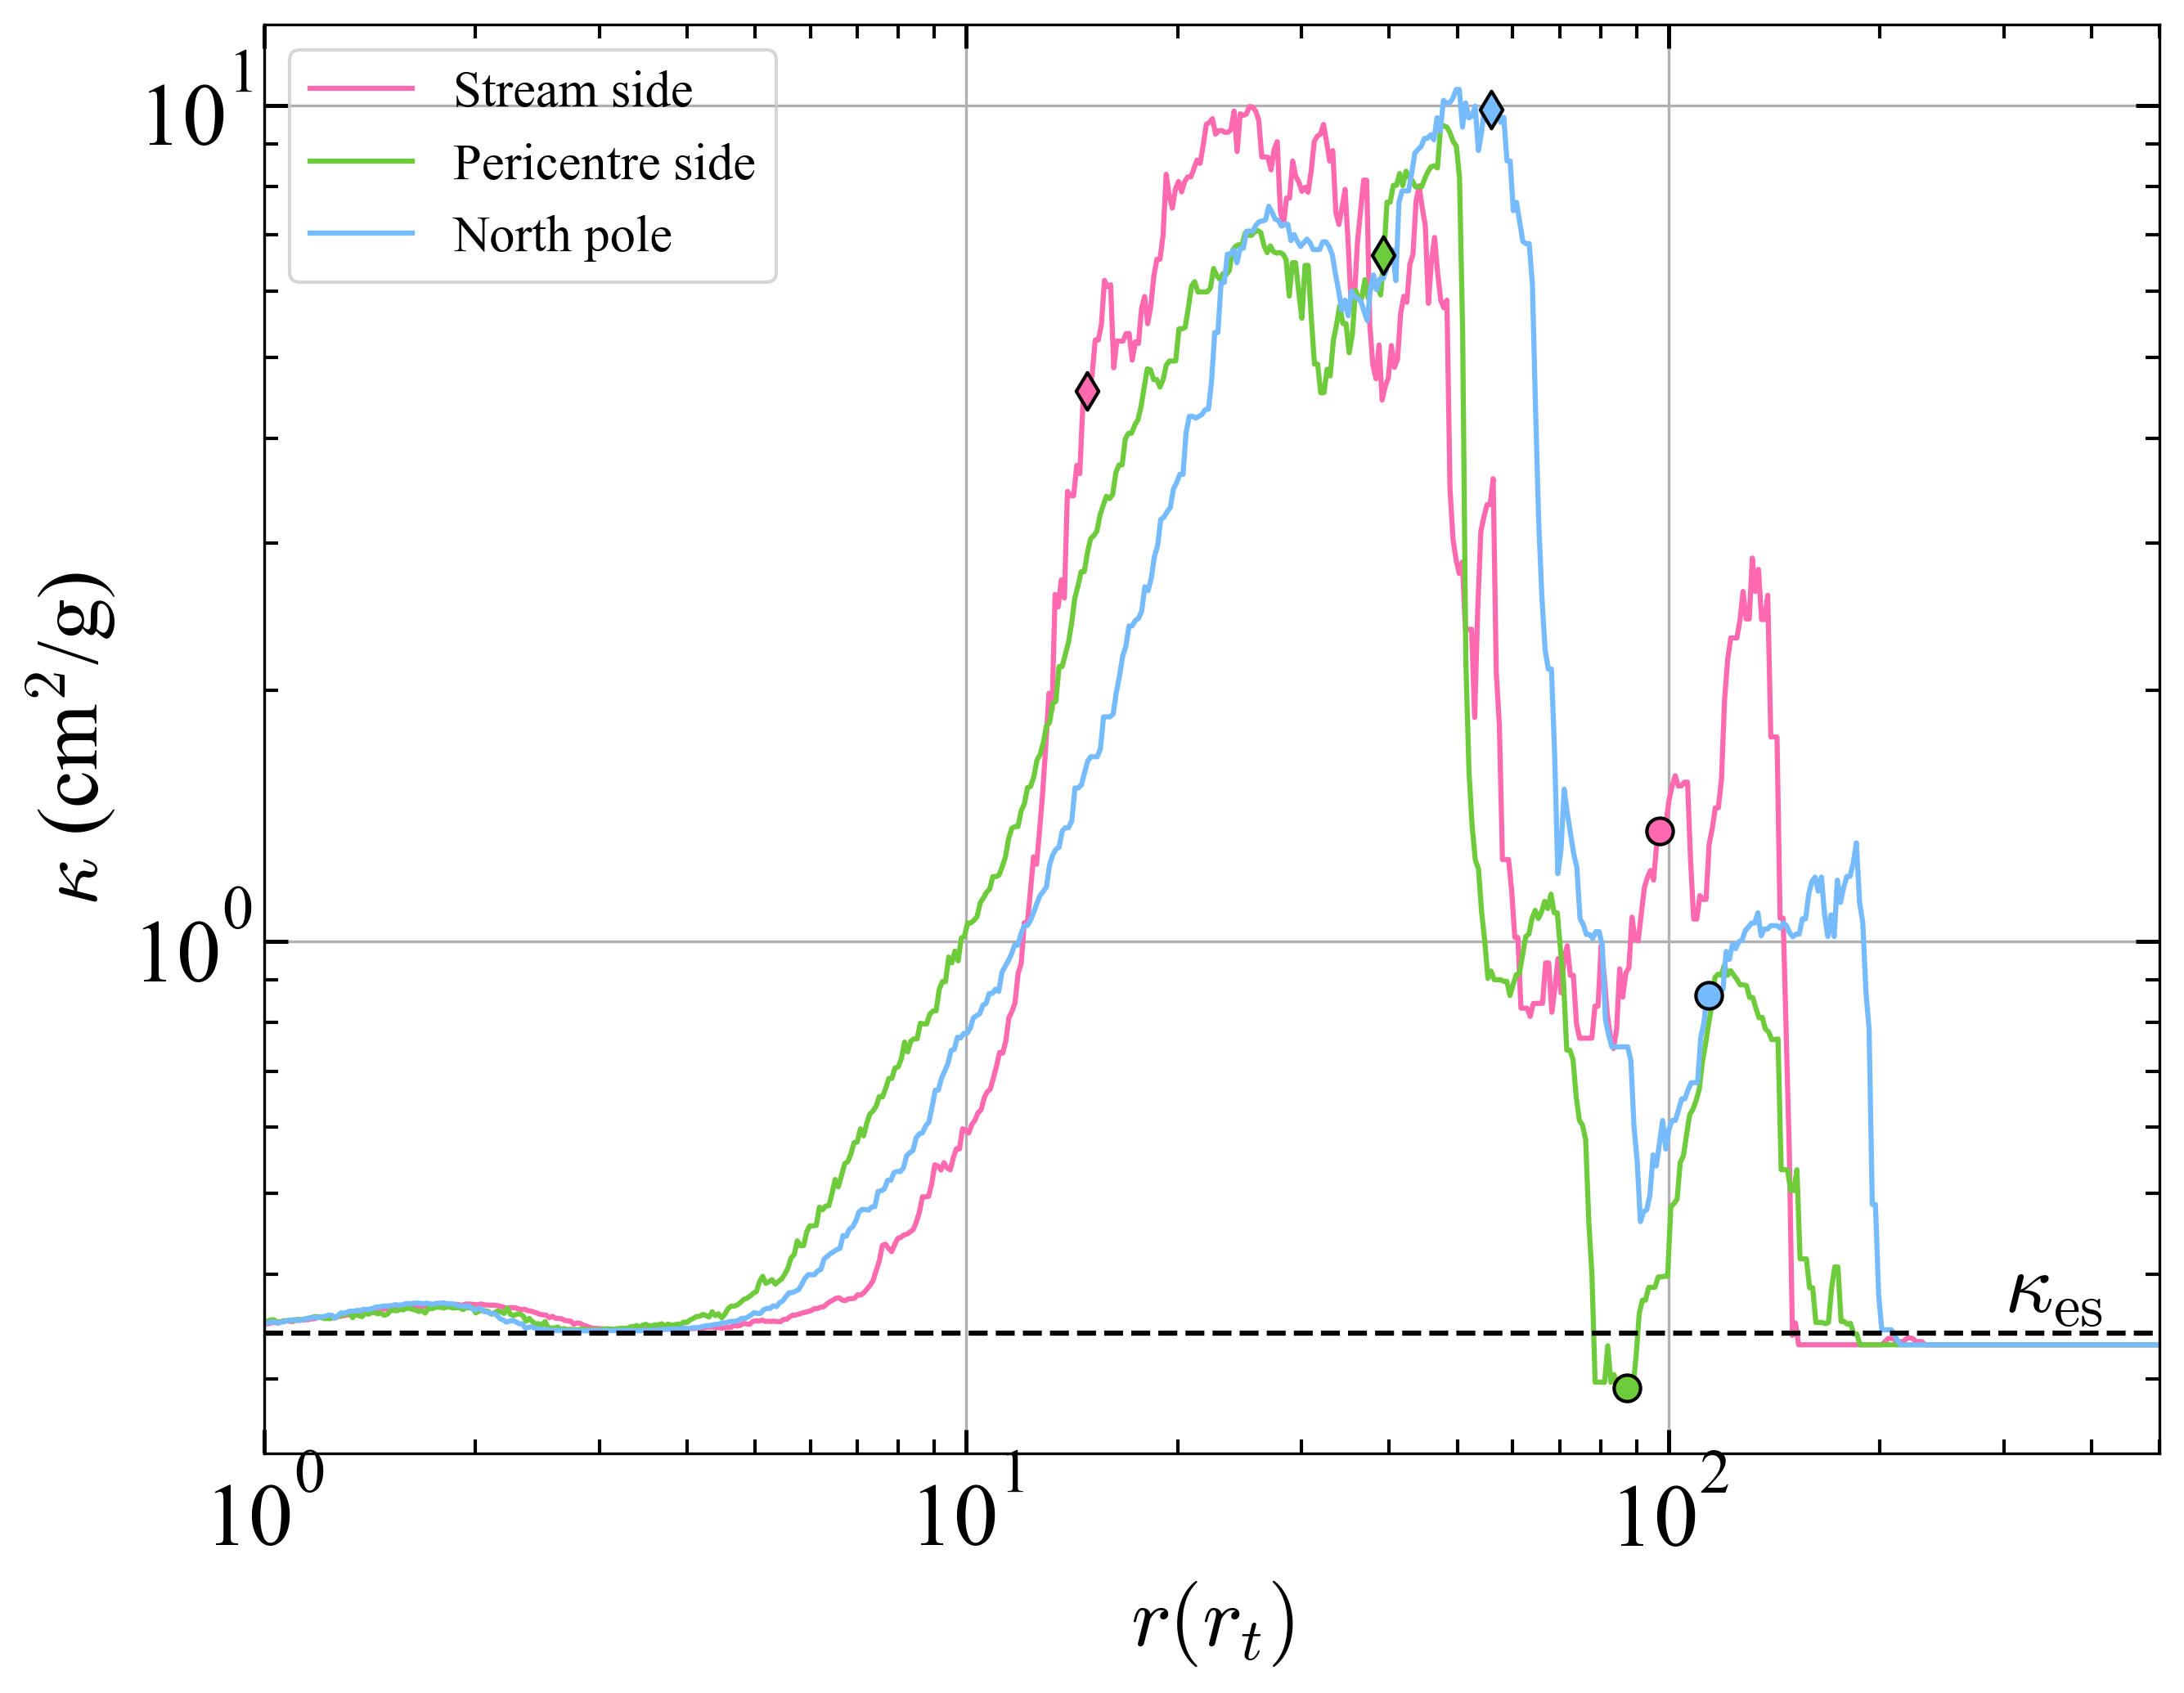

In [ ]:
all_obs = np.load(f'{pre_saving}/kappa_fromFLD{snap}.npy', allow_pickle=True).item()
photo = np.load(f'{abspath}/data/{folder}/photo/{check}_photo{snap}.npz')
xph, yph, zph = photo['x'], photo['y'], photo['z']
rph_all = np.sqrt(xph**2 + yph**2 + zph**2)
pathtrap = f"{abspath}/data/{folder}/trap"
dataRtr = load_and_adjust_rtrap(pathtrap, check, snap)

x_tr, y_tr, z_tr, d_tr, Vr_tr, radden_tr, indices_bigVol, indices_overRph = \
    dataRtr['x_tr'], dataRtr['y_tr'], dataRtr['z_tr'], dataRtr['den_tr'], dataRtr['Vr_tr'], dataRtr['Rad_den_tr'], dataRtr['indices_bigVol'], dataRtr['indices_overRph']
r_tr_all = np.sqrt(x_tr**2 + y_tr**2 + z_tr**2)
r_tr_all[indices_bigVol] = 0
kappa_tr = np.zeros(len(r_tr_all))
# for i, idx_list in enumerate(indices_obs): 
#     rph_medians.append(np.median(rph_all[idx_list]))
#     rtr_medians.append(np.median(r_tr_all[idx_list]))
#     non_zero = idx_list[r_tr_all[idx_list]> Rt]
#     rph_nonzero_medians.append(np.median(rph_all[non_zero]))
#     rtr_nonzero_medians.append(np.median(r_tr_all[non_zero]))

fig, ax = plt.subplots(1,1, figsize=(9, 7))
r_all = []
d_all = []
t_all = []
kappa_all = []

rph_medians = np.zeros(len(indices_obs))
rph_nonzero_medians = np.zeros(len(indices_obs))
rtr_medians = np.zeros(len(indices_obs))
rtr_nonzero_medians = np.zeros(len(indices_obs))
for k, indices in enumerate(indices_obs):
    rph_medians[k] = np.median(rph_all[indices])
    rtr_medians[k] = np.median(r_tr_all[indices])
    non_zero = indices[r_tr_all[indices]> Rt]
    rph_nonzero_medians[k] = np.median(rph_all[non_zero])
    rtr_nonzero_medians[k] = np.median(r_tr_all[non_zero])
    r_sec = []
    d_sec = []
    t_sec = []
    kappa_sec = []
    for i in range(len(observers_xyz)):
        r = all_obs[f'obs_{i}']['r']
        d = all_obs[f'obs_{i}']['d']
        alpha_ross = all_obs[f'obs_{i}']['alpha_rossland']
        idx_tr = np.argmin(np.abs(r - r_tr_all[i]))
        kappa_tr[i] = alpha_ross[idx_tr]/d[idx_tr]
        if i not in indices:
            continue
        t = all_obs[f'obs_{i}']['t']
        r_sec.append(r)
        d_sec.append(d)
        t_sec.append(t)
        kappa_sec.append(alpha_ross/d)
    r_all.append(np.median(np.array(r_sec), axis=0))
    d_all.append(np.median(np.array(d_sec), axis=0))
    t_all.append(np.median(np.array(t_sec), axis=0))
    kappa_all.append(np.median(np.array(kappa_sec), axis=0))
for i in range(len(indices_obs)):
    if i > 2:
        continue
    ax.plot(r_all[i]/Rt, kappa_all[i], label=label_obs[i], color=colors_obs[i])
    idx_rtr = np.argmin(np.abs(r_all[i] - rtr_nonzero_medians[i]))
    idx_rph = np.argmin(np.abs(r_all[i] - rph_nonzero_medians[i]))
    ax.scatter(rph_nonzero_medians[i]/Rt, kappa_all[i][idx_rph], color=colors_obs[i], marker='o', s=60, edgecolors = 'k', zorder=3)
    ax.scatter(rtr_nonzero_medians[i]/Rt, kappa_all[i][idx_rtr], color=colors_obs[i], marker='d', s=60, edgecolors = 'k', zorder=3)
ax.loglog()
ax.set_xlabel(r'$r (r_t)$')
ax.set_ylabel(r'$\kappa$ (cm$^2$/g)')
ax.tick_params(axis='both', which='major', length=7, width=1.2)
ax.tick_params(axis='both', which='minor', length=4, width=1)
ax.set_xlim(1, 5e2)
ax.axhline(0.34, color='k', ls='--', lw=1.5)
ax.text(3e2, 0.36, r'$\kappa_{\rm es}$', fontsize=25)
ax.legend(fontsize=15, loc='upper left')
ax.grid()
plt.tight_layout()
fig.savefig(f'{abspath}/Figs/2.paperWind/opacity.pdf', dpi=300, bbox_inches='tight')